In [1]:
"""
Fragment 1 — Data Loading with Dynamic Per-Class Augmentation
==============================================================
MobileNetV2 Binary Mould Classification Pipeline — Mold vs No Mold

- Discovers mold and no mold classes automatically
- Augments each class up to MAX_TOTAL images then stops
- Saves augmented images to a separate 'augmented' folder
- Builds train and validation generators for model training
- Binary classification — sigmoid output, binary cross-entropy
"""

import os
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array,
)

# ── Configuration ─────────────────────────────────────────────────────────────

MODEL_NAME  = "MobileNetV2"                           # model for this pipeline
DATA_DIR    = r"D:\Mold Studies Binary\Mould Binary Classification"
TRAIN_DIR   = os.path.join(DATA_DIR, "train")
VALID_DIR   = os.path.join(DATA_DIR, "val")
AUG_DIR     = os.path.join(DATA_DIR, "augmented")

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
MAX_TOTAL   = 5000         # each class augmented up to 5000 images

# ── Augmentation Parameters ───────────────────────────────────────────────────

AUG_PARAMS = dict(
    rotation_range      = 20,
    width_shift_range   = 0.1,
    height_shift_range  = 0.1,
    horizontal_flip     = True,
    vertical_flip       = False,
    zoom_range          = 0.15,
    brightness_range    = [0.75, 1.25],
    shear_range         = 0.1,
    channel_shift_range = 10,
    fill_mode           = "nearest",
)

# ── Step 1: Discover Classes ──────────────────────────────────────────────────

def discover_classes(train_dir: str) -> list:
    classes = sorted([
        d.name for d in Path(train_dir).iterdir()
        if d.is_dir()
    ])
    print("=" * 60)
    print(f"  Step 1 — Discovered Classes")
    print("=" * 60)
    print(f"  Model         : {MODEL_NAME}")
    print(f"  Pipeline      : Binary — Mold vs No Mold")
    print()
    for i, cls in enumerate(classes, 1):
        src_count = sum(
            1 for f in (Path(train_dir) / cls).iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png",
                                    ".bmp", ".tiff", ".webp"}
        )
        needed = max(0, MAX_TOTAL - src_count)
        print(f"  {i:>2}. {cls:<22} originals: {src_count:>4}"
              f"   to generate: {needed:>4}")
    print("=" * 60)
    return classes

# ── Step 2: Augment and Save to Disk ─────────────────────────────────────────

def augment_and_save(train_dir: str, aug_dir: str, classes: list,
                     aug_params: dict) -> None:
    """
    For each class:
      - Copies all originals to the augmented folder
      - Generates augmented images one by one until MAX_TOTAL is reached
      - Stops immediately once the cap is hit
    Binary pipeline uses binary class_mode so generators
    will output 0/1 labels matching mold/no mold folders.
    """
    aug_gen  = ImageDataGenerator(**aug_params)
    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

    print("\n" + "=" * 65)
    print(f"  Step 2 — Augmenting & Saving Images to Disk")
    print("=" * 65)
    print(f"  Model       : {MODEL_NAME}")
    print(f"  Source      : {train_dir}")
    print(f"  Destination : {aug_dir}")
    print(f"  Max total   : {MAX_TOTAL} images per class")
    print("=" * 65)

    total_original  = 0
    total_augmented = 0

    for cls in classes:
        src_cls_dir = Path(train_dir) / cls
        dst_cls_dir = Path(aug_dir)   / cls
        dst_cls_dir.mkdir(parents=True, exist_ok=True)

        image_files = [
            f for f in src_cls_dir.iterdir()
            if f.suffix.lower() in IMG_EXTS
            and "_aug_" not in f.stem
        ]

        # ── Copy originals first ──────────────────────────────────────────────
        for img_path in image_files:
            dst = dst_cls_dir / img_path.name
            if not dst.exists():
                img = load_img(img_path, target_size=IMG_SIZE)
                img.save(dst)

        cls_original  = len(image_files)
        cls_aug_count = 0
        needed        = MAX_TOTAL - cls_original

        if needed <= 0:
            print(f"  {cls:<22} | Original: {cls_original:>4}  "
                  f"Augmented:    0  "
                  f"Total: {cls_original:>4}  (no aug needed)")
            total_original += cls_original
            continue

        # ── Generate augmented images until cap is reached ────────────────────
        aug_counter = 0

        while cls_aug_count < needed:
            img_path    = image_files[aug_counter % len(image_files)]
            aug_counter += 1

            img = load_img(img_path, target_size=IMG_SIZE)
            arr = np.expand_dims(img_to_array(img), axis=0)

            aug_iter = aug_gen.flow(
                arr,
                batch_size  = 1,
                save_to_dir = str(dst_cls_dir),
                save_prefix = f"aug_{img_path.stem}_{aug_counter:04d}",
                save_format = "jpg",
            )
            next(aug_iter)
            cls_aug_count += 1

        total_original  += cls_original
        total_augmented += cls_aug_count

        print(f"  {cls:<22} | Original: {cls_original:>4}  "
              f"Augmented: {cls_aug_count:>4}  "
              f"Total: {cls_original + cls_aug_count:>4}")

    print("\n" + "=" * 65)
    print(f"  {'TOTAL':<22} | Original: {total_original:>4}  "
          f"Augmented: {total_augmented:>4}  "
          f"Total: {total_original + total_augmented:>4}")
    print("=" * 65)
    print(f"\n  ✓ Augmented images saved to: {aug_dir}\n")

# ── Step 3: Build Generators ──────────────────────────────────────────────────

def build_generators(aug_dir: str, valid_dir: str):
    """
    Builds train generator from augmented folder and
    validation generator from val folder.
    class_mode = 'binary' — outputs 0/1 labels for
    mold/no mold binary classification.
    MobileNetV2 preprocessing applied via rescale 1/255.
    shuffle=True on train, shuffle=False on val.
    """

    train_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    train_generator = train_datagen.flow_from_directory(
        aug_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = True,
    )

    valid_datagen   = ImageDataGenerator(rescale=1.0 / 255)
    valid_generator = valid_datagen.flow_from_directory(
        valid_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    print("\n" + "=" * 60)
    print(f"  Step 3 — Data Generators Ready")
    print("=" * 60)
    print(f"  Model         : {MODEL_NAME}")
    print(f"  Pipeline      : Binary — Mold vs No Mold")
    print(f"  Train source  : augmented/")
    print(f"  Valid source  : val/")
    print(f"  Train samples : {train_generator.samples}")
    print(f"  Valid samples : {valid_generator.samples}")
    print(f"  Class indices : {train_generator.class_indices}")
    print(f"  Image size    : {IMG_SIZE}")
    print(f"  Batch size    : {BATCH_SIZE}")
    print(f"  Class mode    : binary (0/1 labels)")
    print("=" * 60)

    return train_generator, valid_generator

# ── Run Fragment 1 ────────────────────────────────────────────────────────────

classes = discover_classes(TRAIN_DIR)
augment_and_save(TRAIN_DIR, AUG_DIR, classes, AUG_PARAMS)
train_generator, valid_generator = build_generators(AUG_DIR, VALID_DIR)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("\n  ✓ Fragment 1 complete.")
print(f"     Model         : {MODEL_NAME}")
print(f"     Classes       : {CLASS_NAMES}")
print(f"     Class mode    : binary (0/1 labels)")
print(f"     train_generator and valid_generator ready.")
print(f"     Proceed to Fragment 2 — {MODEL_NAME} Model Training.\n")


  Step 1 — Discovered Classes
  Model         : MobileNetV2
  Pipeline      : Binary — Mold vs No Mold

   1. Mold                   originals: 1288   to generate: 3712
   2. No mold                originals: 1736   to generate: 3264

  Step 2 — Augmenting & Saving Images to Disk
  Model       : MobileNetV2
  Source      : D:\Mold Studies Binary\Mould Binary Classification\train
  Destination : D:\Mold Studies Binary\Mould Binary Classification\augmented
  Max total   : 5000 images per class
  Mold                   | Original: 1288  Augmented: 3712  Total: 5000
  No mold                | Original: 1736  Augmented: 3264  Total: 5000

  TOTAL                  | Original: 3024  Augmented: 6976  Total: 10000

  ✓ Augmented images saved to: D:\Mold Studies Binary\Mould Binary Classification\augmented

Found 10000 images belonging to 2 classes.
Found 648 images belonging to 2 classes.

  Step 3 — Data Generators Ready
  Model         : MobileNetV2
  Pipeline      : Binary — Mold vs No Mold

In [2]:
"""
Fragment 2 — MobileNetV2 Model Building with Transfer Learning
==============================================================
Binary Mould Classification Pipeline — Mold vs No Mold

- Loads MobileNetV2 with ImageNet weights
- Accepts learning rate, dropout rate and unfreeze depth as inputs
- Freezes base layers except last N unfrozen layers
- Adds custom binary classification head
- Sigmoid output with binary cross-entropy loss
- Compiled and ready for training
"""

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.optimizers import Adam

# ── Configuration ─────────────────────────────────────────────────────────────

IMG_SIZE    = (224, 224)
IMG_SHAPE   = IMG_SIZE + (3,)
NUM_CLASSES = len(train_generator.class_indices)
CLASS_NAMES = list(train_generator.class_indices.keys())

# ── Default values ────────────────────────────────────────────────────────────

DEFAULT_LEARNING_RATE   = 1e-4
DEFAULT_DROPOUT_RATE    = 0.3
DEFAULT_UNFREEZE_LAYERS = 0
EPOCHS                  = 25

# ── Step 1: Model Builder ─────────────────────────────────────────────────────

def build_mobilenet_binary(learning_rate, dropout_rate, unfreeze_layers,
                            epochs=EPOCHS):
    """
    Builds and compiles MobileNetV2 for binary classification.

    Parameters
    ----------
    learning_rate   : float — Adam optimizer learning rate
    dropout_rate    : float — dropout applied in classification head
    unfreeze_layers : int   — number of base layers unfrozen from the top
                              0 = fully frozen, feature extraction only
    epochs          : int   — number of training epochs

    Architecture change from multiclass:
    - Output layer uses Dense(1, sigmoid) instead of Dense(N, softmax)
    - Loss is binary_crossentropy instead of categorical_crossentropy
    - Metrics include AUC in addition to accuracy for binary evaluation
    """

    # ── Load MobileNetV2 with ImageNet weights ────────────────────────────────
    base_model = MobileNetV2(
        input_shape = IMG_SHAPE,
        include_top = False,
        weights     = "imagenet"
    )

    # ── Freeze all base layers first ──────────────────────────────────────────
    base_model.trainable = False

    # ── Unfreeze last N layers (skip BatchNorm layers) ────────────────────────
    if unfreeze_layers > 0:
        for layer in base_model.layers[-unfreeze_layers:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    # ── Binary classification head ────────────────────────────────────────────
    x      = base_model.output
    x      = GlobalAveragePooling2D(name="global_avg_pool")(x)
    x      = BatchNormalization(name="head_batch_norm")(x)
    x      = Dense(256, activation="relu", name="dense_256")(x)
    x      = Dropout(dropout_rate, name="dropout_1")(x)
    x      = Dense(128, activation="relu", name="dense_128")(x)
    x      = Dropout(dropout_rate / 2, name="dropout_2")(x)
    output = Dense(1, activation="sigmoid", name="output")(x)

    # ── Assemble model ────────────────────────────────────────────────────────
    model = Model(inputs=base_model.input, outputs=output)

    # ── Compile with binary loss and AUC metric ───────────────────────────────
    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss      = "binary_crossentropy",
        metrics   = [
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
        ]
    )

    return model

# ── Step 2: Build default model and print summary ─────────────────────────────

model = build_mobilenet_binary(
    learning_rate   = DEFAULT_LEARNING_RATE,
    dropout_rate    = DEFAULT_DROPOUT_RATE,
    unfreeze_layers = DEFAULT_UNFREEZE_LAYERS,
)

# ── Count parameters ──────────────────────────────────────────────────────────
total_params     = model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen_params    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)

unfrozen_base = sum(
    1 for l in model.layers
    if l.trainable and l.name not in
    ["global_avg_pool", "head_batch_norm",
     "dense_256", "dropout_1",
     "dense_128", "dropout_2", "output"]
)

print("=" * 60)
print("  Fragment 2 — MobileNetV2 Binary Classification")
print("=" * 60)

print("\n  ── Inputs ──────────────────────────────────────────")
print(f"  Learning rate    : {DEFAULT_LEARNING_RATE}")
print(f"  Dropout rate     : {DEFAULT_DROPOUT_RATE}")
print(f"  Unfreeze layers  : {DEFAULT_UNFREEZE_LAYERS}")

print("\n  ── Base Model ──────────────────────────────────────")
print(f"  Architecture     : MobileNetV2")
print(f"  Weights          : ImageNet ✓")
print(f"  Input shape      : {IMG_SHAPE}")
print(f"  Unfrozen layers  : {unfrozen_base}")

print("\n  ── Classification Head ─────────────────────────────")
print(f"  GlobalAveragePooling2D")
print(f"  BatchNormalization")
print(f"  Dense(256, relu)")
print(f"  Dropout({DEFAULT_DROPOUT_RATE})")
print(f"  Dense(128, relu)")
print(f"  Dropout({DEFAULT_DROPOUT_RATE / 2})")
print(f"  Dense(1, sigmoid)  ← binary output")

print("\n  ── Loss & Metrics ──────────────────────────────────")
print(f"  Loss             : binary_crossentropy")
print(f"  Metrics          : accuracy, AUC")
print(f"  Classes          : {CLASS_NAMES}")
print(f"  Class indices    : {train_generator.class_indices}")

print("\n  ── Parameters ──────────────────────────────────────")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable        : {trainable_params:,}")
print(f"  Frozen           : {frozen_params:,}")

print("\n  ── Training ────────────────────────────────────────")
print(f"  Epochs           : {EPOCHS}")
print(f"  Optimizer        : Adam(lr={DEFAULT_LEARNING_RATE})")
print("=" * 60)

print("\n  ✓ Fragment 2 complete. build_mobilenet_binary() is ready.")
print("     Proceed to Fragment 3 — Training.\n")



  Fragment 2 — MobileNetV2 Binary Classification

  ── Inputs ──────────────────────────────────────────
  Learning rate    : 0.0001
  Dropout rate     : 0.3
  Unfreeze layers  : 0

  ── Base Model ──────────────────────────────────────
  Architecture     : MobileNetV2
  Weights          : ImageNet ✓
  Input shape      : (224, 224, 3)
  Unfrozen layers  : 0

  ── Classification Head ─────────────────────────────
  GlobalAveragePooling2D
  BatchNormalization
  Dense(256, relu)
  Dropout(0.3)
  Dense(128, relu)
  Dropout(0.15)
  Dense(1, sigmoid)  ← binary output

  ── Loss & Metrics ──────────────────────────────────
  Loss             : binary_crossentropy
  Metrics          : accuracy, AUC
  Classes          : ['Mold', 'No mold']
  Class indices    : {'Mold': 0, 'No mold': 1}

  ── Parameters ──────────────────────────────────────
  Total params     : 2,624,065
  Trainable        : 363,521
  Frozen           : 2,260,544

  ── Training ────────────────────────────────────────
  Epoch

In [3]:
"""
Fragment 3 — Callbacks & Model Training
========================================
Binary Mould Classification Pipeline — Mold vs No Mold

- Defines all callbacks:
    * ModelCheckpoint    — saves best model based on val_auc
    * EarlyStopping      — stops training if no improvement
    * ReduceLROnPlateau  — reduces LR when val_loss stalls
    * CSVLogger          — logs all metrics per epoch to CSV
- Trains MobileNetV2 binary classifier
- Validates on val set only
- Stores history for Fragment 4 evaluation:
    * Accuracy, Loss, AUC curves
    * Sensitivity, Specificity, F1
    * Confusion Matrix (2x2)
    * ROC curve
"""

import os
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR     = r"D:\Mold Studies Binary\Models"
MODEL_NAME   = "mobilenetv2_binary_best.keras"
CSV_LOG_NAME = "mobilenetv2_binary_training_log.csv"

os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
CSV_PATH   = os.path.join(SAVE_DIR, CSV_LOG_NAME)

# ── Callback Parameters ───────────────────────────────────────────────────────

ES_PATIENCE     = 10
ES_MIN_DELTA    = 1e-4

RLROP_FACTOR    = 0.5
RLROP_PATIENCE  = 5
RLROP_MIN_LR    = 1e-7
RLROP_MIN_DELTA = 1e-4

# ── Step 1: Define Callbacks ──────────────────────────────────────────────────

# Monitor val_auc instead of val_accuracy — more meaningful
# for binary classification especially with class imbalance
# AUC captures the tradeoff between sensitivity and specificity

checkpoint = ModelCheckpoint(
    filepath          = MODEL_PATH,
    monitor           = "val_auc",
    save_best_only    = True,
    save_weights_only = False,
    mode              = "max",
    verbose           = 1,
)

early_stopping = EarlyStopping(
    monitor              = "val_auc",
    patience             = ES_PATIENCE,
    min_delta            = ES_MIN_DELTA,
    mode                 = "max",
    restore_best_weights = True,
    verbose              = 1,
)

reduce_lr = ReduceLROnPlateau(
    monitor   = "val_loss",
    factor    = RLROP_FACTOR,
    patience  = RLROP_PATIENCE,
    min_lr    = RLROP_MIN_LR,
    min_delta = RLROP_MIN_DELTA,
    mode      = "min",
    verbose   = 1,
)

csv_logger = CSVLogger(
    filename  = CSV_PATH,
    separator = ",",
    append    = False,
)

callbacks = [checkpoint, early_stopping, reduce_lr, csv_logger]

print("=" * 60)
print("  Step 1 — Callbacks Configured")
print("=" * 60)
print(f"  ModelCheckpoint  : best val_auc → {MODEL_PATH}")
print(f"  EarlyStopping    : patience={ES_PATIENCE} epochs, "
      f"restores best weights")
print(f"  ReduceLROnPlateau: factor={RLROP_FACTOR} after "
      f"{RLROP_PATIENCE} stale epochs, floor={RLROP_MIN_LR}")
print(f"  CSVLogger        : epoch log → {CSV_PATH}")
print("=" * 60)

# ── Step 2: Training Configuration ───────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 2 — Training Configuration")
print("=" * 60)
print(f"  Pipeline         : Binary — Mold vs No Mold")
print(f"  Train samples    : {train_generator.samples}")
print(f"  Valid samples    : {valid_generator.samples}")
print(f"  Classes          : {CLASS_NAMES}")
print(f"  Class indices    : {train_generator.class_indices}")
print(f"  Epochs           : {EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Learning rate    : {DEFAULT_LEARNING_RATE:.6f}")
print(f"  Dropout rate     : {DEFAULT_DROPOUT_RATE:.4f}")
print(f"  Unfreeze layers  : {DEFAULT_UNFREEZE_LAYERS}")
print(f"  Loss             : binary_crossentropy")
print(f"  Monitor          : val_auc")
print("=" * 60 + "\n")

# ── Step 3: Build Final Model ─────────────────────────────────────────────────

model = build_mobilenet_binary(
    learning_rate   = DEFAULT_LEARNING_RATE,
    dropout_rate    = DEFAULT_DROPOUT_RATE,
    unfreeze_layers = DEFAULT_UNFREEZE_LAYERS,
    epochs          = EPOCHS,
)

# ── Step 4: Train ─────────────────────────────────────────────────────────────

history = model.fit(
    train_generator,
    epochs           = EPOCHS,
    validation_data  = valid_generator,
    callbacks        = callbacks,
    steps_per_epoch  = train_generator.samples  // BATCH_SIZE,
    validation_steps = valid_generator.samples  // BATCH_SIZE,
)

# ── Step 5: Training Summary ──────────────────────────────────────────────────

best_val_auc  = max(history.history["val_auc"])
best_val_acc  = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])
epochs_run    = len(history.history["accuracy"])
best_epoch    = history.history["val_auc"].index(best_val_auc) + 1

print("\n" + "=" * 60)
print("  Step 5 — Training Complete")
print("=" * 60)
print(f"  Epochs run       : {epochs_run} / {EPOCHS}")
print(f"  Best epoch       : {best_epoch}")
print(f"  Best val AUC     : {best_val_auc:.4f}")
print(f"  Best val accuracy: {best_val_acc:.4f}  ({best_val_acc * 100:.2f}%)")
print(f"  Best val loss    : {best_val_loss:.4f}")
print(f"  Best model saved : {MODEL_PATH}")
print(f"  Training log     : {CSV_PATH}")
print("=" * 60)

print("\n  ── Metrics available for Fragment 4 evaluation ─────")
print("  ✓ Accuracy        — per epoch (train + val)")
print("  ✓ AUC             — per epoch (train + val)")
print("  ✓ Loss            — per epoch (train + val)")
print("  ✓ Sensitivity     — computed from confusion matrix")
print("  ✓ Specificity     — computed from confusion matrix")
print("  ✓ F1 Score        — computed from confusion matrix")
print("  ✓ ROC Curve       — binary single curve")
print("  ✓ Confusion Matrix — 2x2 matrix (mold / no mold)")
print("=" * 60)

print("\n  ✓ Fragment 3 complete. history and model are ready.")
print("     Proceed to Fragment 4 — Evaluation & Metrics.\n")

  Step 1 — Callbacks Configured
  ModelCheckpoint  : best val_auc → D:\Mold Studies Binary\Models\mobilenetv2_binary_best.keras
  EarlyStopping    : patience=10 epochs, restores best weights
  ReduceLROnPlateau: factor=0.5 after 5 stale epochs, floor=1e-07
  CSVLogger        : epoch log → D:\Mold Studies Binary\Models\mobilenetv2_binary_training_log.csv

  Step 2 — Training Configuration
  Pipeline         : Binary — Mold vs No Mold
  Train samples    : 10000
  Valid samples    : 648
  Classes          : ['Mold', 'No mold']
  Class indices    : {'Mold': 0, 'No mold': 1}
  Epochs           : 25
  Batch size       : 32
  Learning rate    : 0.000100
  Dropout rate     : 0.3000
  Unfreeze layers  : 0
  Loss             : binary_crossentropy
  Monitor          : val_auc

Epoch 1/25


312/312 [==============================] - ETA: 0s - loss: 0.4471 - accuracy: 0.7830 - auc: 0.8698
Epoch 1: val_auc improved from -inf to 0.96129, saving model to D:\Mold Studies Binary\Models\mobilenetv2_binar

In [4]:
"""
Fragment 3b — Multi-Run Training (MobileNetV2 Binary)
======================================================
Binary Mould Classification Pipeline — Mold vs No Mold

Runs 4 additional independent training loops (Runs 2–5).
Run 1 was completed in Fragment 3 and its model is already saved.
Each run starts from fresh ImageNet weights with randomly
reinitialised classification head.

OUTPUT: 5 models saved to disk for statistical analysis
    mobilenetv2_binary_run1_best.keras   (copied from Fragment 3)
    mobilenetv2_binary_run2_best.keras
    mobilenetv2_binary_run3_best.keras
    mobilenetv2_binary_run4_best.keras
    mobilenetv2_binary_run5_best.keras

DATA BOUNDARIES — unchanged from Fragment 3:
    Training   : train_generator  (augmented folder)
    Validation : valid_generator  (val folder)
    Test       : NOT TOUCHED — Fragment 4 only
"""

import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies Binary\Models"
TOTAL_RUNS = 5

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Step 1: Rename Fragment 3 model → Run 1 ──────────────────────────────────

src = os.path.join(SAVE_DIR, "mobilenetv2_binary_best.keras")
dst = os.path.join(SAVE_DIR, "mobilenetv2_binary_run1_best.keras")

if os.path.exists(src) and not os.path.exists(dst):
    shutil.copy2(src, dst)
    print(f"  Copied  : mobilenetv2_binary_best.keras "
          f"→ mobilenetv2_binary_run1_best.keras")
elif os.path.exists(dst):
    print(f"  Already exists : mobilenetv2_binary_run1_best.keras "
          f"— skipping copy")
else:
    print(f"  WARNING : mobilenetv2_binary_best.keras not found")
    print(f"            Ensure Fragment 3 completed successfully "
          f"before continuing")

# ── Step 2: Collect Run 1 results from Fragment 3 ────────────────────────────

all_run_results = [
    {
        "run"          : 1,
        "best_val_auc" : best_val_auc,
        "best_val_acc" : best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch"   : best_epoch,
        "checkpoint"   : "mobilenetv2_binary_run1_best.keras"
    }
]

print(f"\n  Run 1 loaded from Fragment 3")
print(f"    Best val AUC      : {best_val_auc:.4f}")
print(f"    Best val accuracy : {best_val_acc:.4f}")
print(f"    Best val loss     : {best_val_loss:.4f}")
print(f"    Best epoch        : {best_epoch}")

# ── Step 3: Runs 2–5 ──────────────────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  MULTI-RUN TRAINING — Runs 2 to {TOTAL_RUNS}")
print(f"  Each run : fresh ImageNet weights, random head init")
print(f"  Epochs   : {EPOCHS}")
print(f"  LR       : {DEFAULT_LEARNING_RATE}")
print(f"  Dropout  : {DEFAULT_DROPOUT_RATE}")
print(f"  Unfreeze : {DEFAULT_UNFREEZE_LAYERS} layers")
print(f"  Monitor  : val_auc")
print(f"{'='*60}")

for run_idx in range(2, TOTAL_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}")
    print(f"{'='*60}\n")

    ckpt_path = os.path.join(SAVE_DIR,
                             f"mobilenetv2_binary_run{run_idx}_best.keras")
    csv_path  = os.path.join(SAVE_DIR,
                             f"mobilenetv2_binary_run{run_idx}_log.csv")

    # ── Fresh model — new random head, ImageNet backbone ──────────────────────
    run_model = build_mobilenet_binary(
        learning_rate   = DEFAULT_LEARNING_RATE,
        dropout_rate    = DEFAULT_DROPOUT_RATE,
        unfreeze_layers = DEFAULT_UNFREEZE_LAYERS,
        epochs          = EPOCHS,
    )

    # ── Run-specific callbacks ─────────────────────────────────────────────────
    run_callbacks = [
        ModelCheckpoint(
            filepath          = ckpt_path,
            monitor           = "val_auc",
            save_best_only    = True,
            save_weights_only = False,
            save_format       = "keras",
            mode              = "max",
            verbose           = 1,
        ),
        EarlyStopping(
            monitor              = "val_auc",
            patience             = ES_PATIENCE,
            min_delta            = ES_MIN_DELTA,
            mode                 = "max",
            restore_best_weights = True,
            verbose              = 1,
        ),
        ReduceLROnPlateau(
            monitor   = "val_loss",
            factor    = RLROP_FACTOR,
            patience  = RLROP_PATIENCE,
            min_lr    = RLROP_MIN_LR,
            min_delta = RLROP_MIN_DELTA,
            mode      = "min",
            verbose   = 1,
        ),
        CSVLogger(
            filename  = csv_path,
            separator = ",",
            append    = False,
        ),
    ]

    # ── Train ──────────────────────────────────────────────────────────────────
    run_history = run_model.fit(
        train_generator,
        validation_data  = valid_generator,
        epochs           = EPOCHS,
        callbacks        = run_callbacks,
        steps_per_epoch  = train_generator.samples  // BATCH_SIZE,
        validation_steps = valid_generator.samples  // BATCH_SIZE,
    )

    # ── Extract best metrics ───────────────────────────────────────────────────
    run_best_val_auc  = max(run_history.history["val_auc"])
    run_best_val_acc  = max(run_history.history["val_accuracy"])
    run_best_val_loss = min(run_history.history["val_loss"])
    run_best_epoch    = run_history.history["val_auc"].index(
                            run_best_val_auc) + 1
    run_epochs_run    = len(run_history.history["accuracy"])

    run_model.save(ckpt_path)

    all_run_results.append({
        "run"          : run_idx,
        "best_val_auc" : run_best_val_auc,
        "best_val_acc" : run_best_val_acc,
        "best_val_loss": run_best_val_loss,
        "best_epoch"   : run_best_epoch,
        "checkpoint"   : f"mobilenetv2_binary_run{run_idx}_best.keras"
    })

    print(f"\n  Run {run_idx} complete")
    print(f"    Epochs run        : {run_epochs_run} / {EPOCHS}")
    print(f"    Best epoch        : {run_best_epoch}")
    print(f"    Best val AUC      : {run_best_val_auc:.4f}")
    print(f"    Best val accuracy : {run_best_val_acc:.4f}")
    print(f"    Best val loss     : {run_best_val_loss:.4f}")
    print(f"    Saved to          : {ckpt_path}")

# ── Step 4: Summary across all 5 runs ────────────────────────────────────────

val_aucs   = [r["best_val_auc"]  for r in all_run_results]
val_accs   = [r["best_val_acc"]  for r in all_run_results]
val_losses = [r["best_val_loss"] for r in all_run_results]

print(f"\n{'='*60}")
print(f"  ALL RUNS COMPLETE — Summary")
print(f"{'='*60}")
print(f"  {'Run':<6} {'Val AUC':>10} {'Val Acc':>10} "
      f"{'Val Loss':>10} {'Best Epoch':>12} {'Checkpoint'}")
print(f"  {'─'*80}")

for r in all_run_results:
    print(f"  {r['run']:<6} {r['best_val_auc']:>10.4f} "
          f"{r['best_val_acc']:>10.4f} {r['best_val_loss']:>10.4f} "
          f"{r['best_epoch']:>12} {r['checkpoint']}")

best_run = max(all_run_results, key=lambda x: x["best_val_auc"])

print(f"\n  {'─'*60}")
print(f"  Mean val AUC       : {np.mean(val_aucs):.4f}")
print(f"  Std  val AUC       : {np.std(val_aucs):.4f}")
print(f"  Mean val accuracy  : {np.mean(val_accs):.4f}")
print(f"  Std  val accuracy  : {np.std(val_accs):.4f}")
print(f"  Mean val loss      : {np.mean(val_losses):.4f}")
print(f"  Std  val loss      : {np.std(val_losses):.4f}")
print(f"\n  Best single run    : Run {best_run['run']} "
      f"— Val AUC {best_run['best_val_auc']:.4f}")
print(f"{'='*60}")

# ── Step 5: Expose checkpoint list for Fragment 4 ────────────────────────────

ensemble_checkpoints = [
    os.path.join(SAVE_DIR, r["checkpoint"]) for r in all_run_results
]

print(f"\n  ✓ Fragment 3b complete.")
print(f"  ensemble_checkpoints = {ensemble_checkpoints}")
print(f"\n     Proceed to Fragment 4 — Evaluation & Metrics.\n")

  Copied  : mobilenetv2_binary_best.keras → mobilenetv2_binary_run1_best.keras

  Run 1 loaded from Fragment 3
    Best val AUC      : 0.9917
    Best val accuracy : 0.9578
    Best val loss     : 0.1193
    Best epoch        : 8

  MULTI-RUN TRAINING — Runs 2 to 5
  Each run : fresh ImageNet weights, random head init
  Epochs   : 25
  LR       : 0.0001
  Dropout  : 0.3
  Unfreeze : 0 layers
  Monitor  : val_auc

  RUN 2 / 5

Epoch 1/25
312/312 [==============================] - ETA: 0s - loss: 0.4571 - accuracy: 0.7822 - auc: 0.8660
Epoch 1: val_auc improved from -inf to 0.96199, saving model to D:\Mold Studies Binary\Models\mobilenetv2_binary_run2_best.keras
312/312 [==============================] - 37s 115ms/step - loss: 0.4571 - accuracy: 0.7822 - auc: 0.8660 - val_loss: 0.2746 - val_accuracy: 0.8875 - val_auc: 0.9620 - lr: 1.0000e-04
Epoch 2/25
312/312 [==============================] - ETA: 0s - loss: 0.2741 - accuracy: 0.8830 - auc: 0.9541
Epoch 2: val_auc improved from 0.96199

Found 649 images belonging to 2 classes.
  Step 1 — Test Generator Ready
  Architecture  : MobileNetV2 Binary
  Preprocessing : preprocess_input (MobileNetV2)
  Test samples  : 649
  Classes       : ['Mold', 'No mold']
  Class indices : {'Mold': 0, 'No mold': 1}
  Threshold     : 0.5
  Source        : D:\Mold Studies Binary\Mould Binary Classification\test

  Evaluating MobileNetV2 Binary Run 1 / 5
  Checkpoint : D:\Mold Studies Binary\Models\mobilenetv2_binary_run1_best.keras
21/21 [==============================] - 7s 312ms/step

  Run 1 Results
    Accuracy     : 0.8598
    Precision    : 0.8649
    Sensitivity  : 0.8952
    Specificity  : 0.8123
    F1 Score     : 0.8798
    AUC          : 0.9344
    TP=333  TN=225  FP=52  FN=39


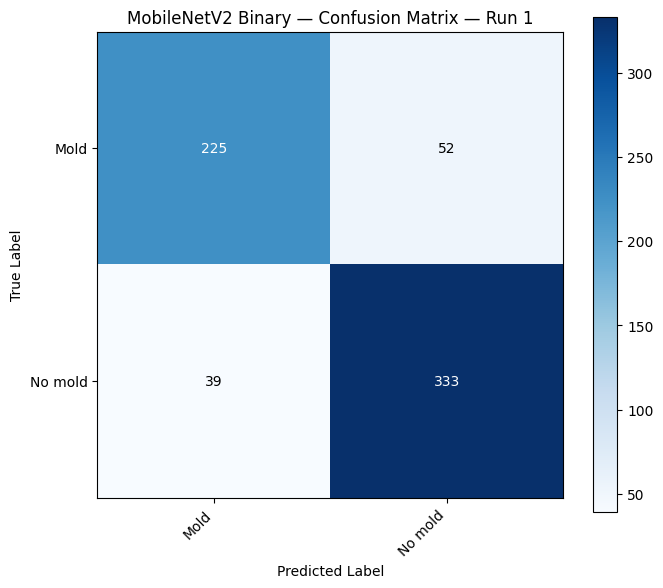

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_confusion_matrix_run1.png


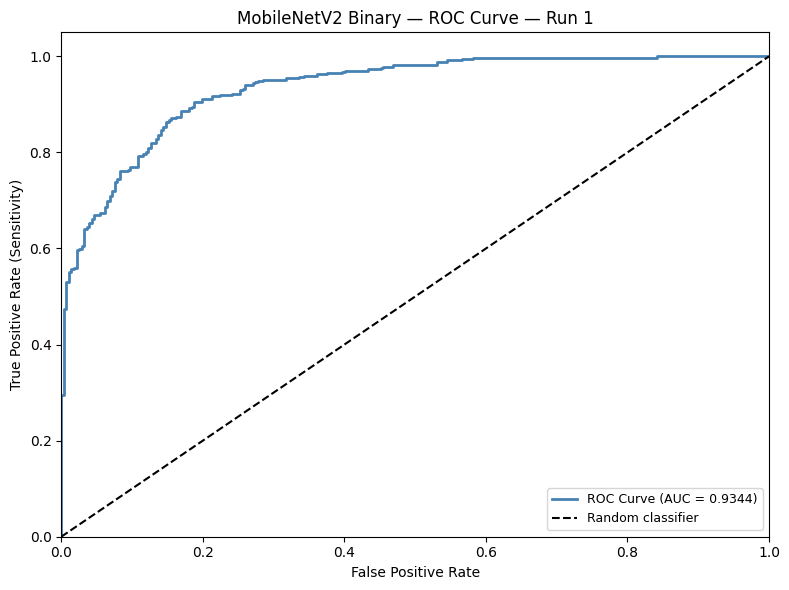

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_roc_curve_run1.png


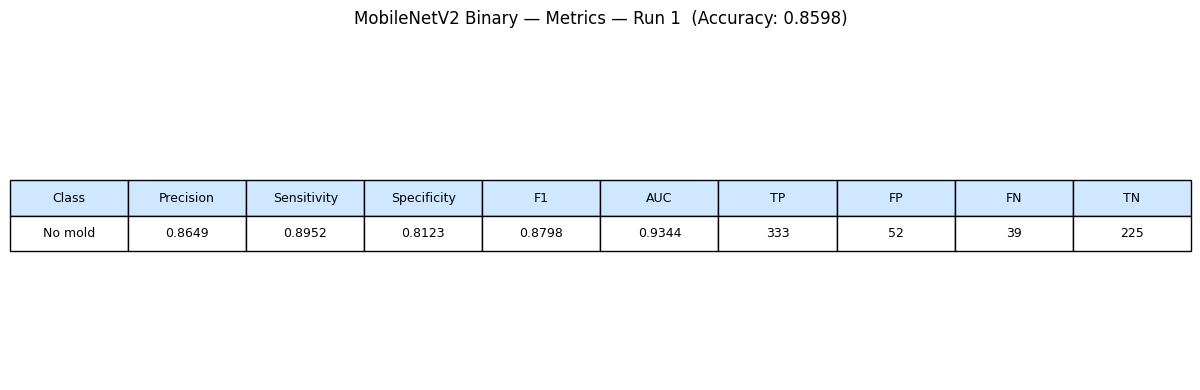

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_metrics_table_run1.png


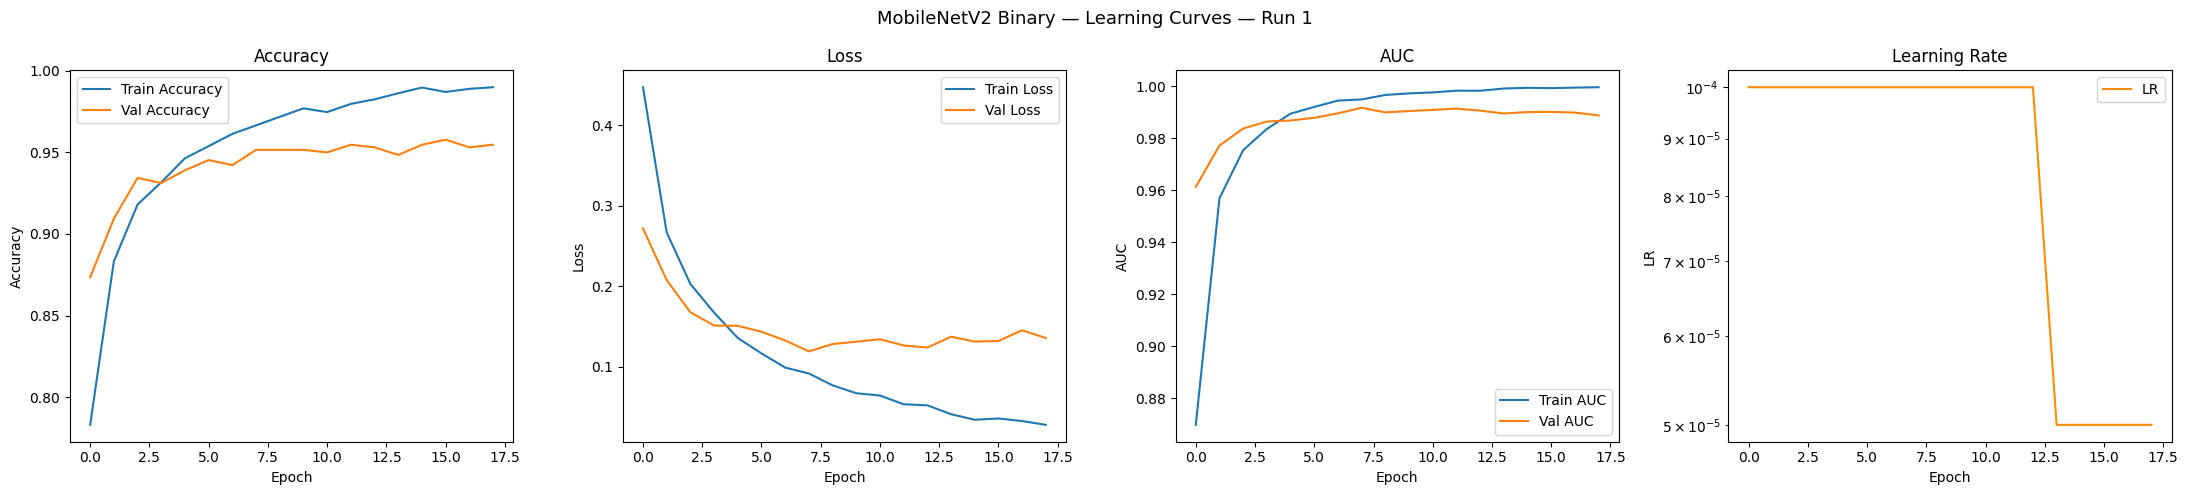

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_learning_curves_run1.png

  Evaluating MobileNetV2 Binary Run 2 / 5
  Checkpoint : D:\Mold Studies Binary\Models\mobilenetv2_binary_run2_best.keras
21/21 [==============================] - 3s 106ms/step

  Run 2 Results
    Accuracy     : 0.8552
    Precision    : 0.8840
    Sensitivity  : 0.8602
    Specificity  : 0.8484
    F1 Score     : 0.8719
    AUC          : 0.9302
    TP=320  TN=235  FP=42  FN=52


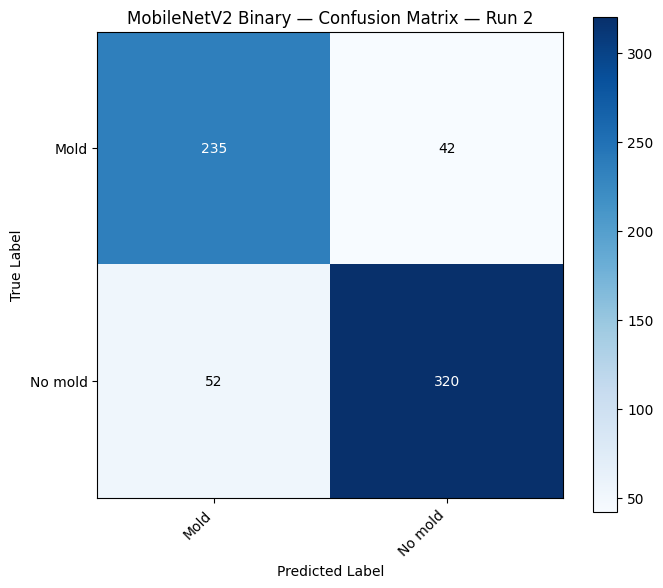

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_confusion_matrix_run2.png


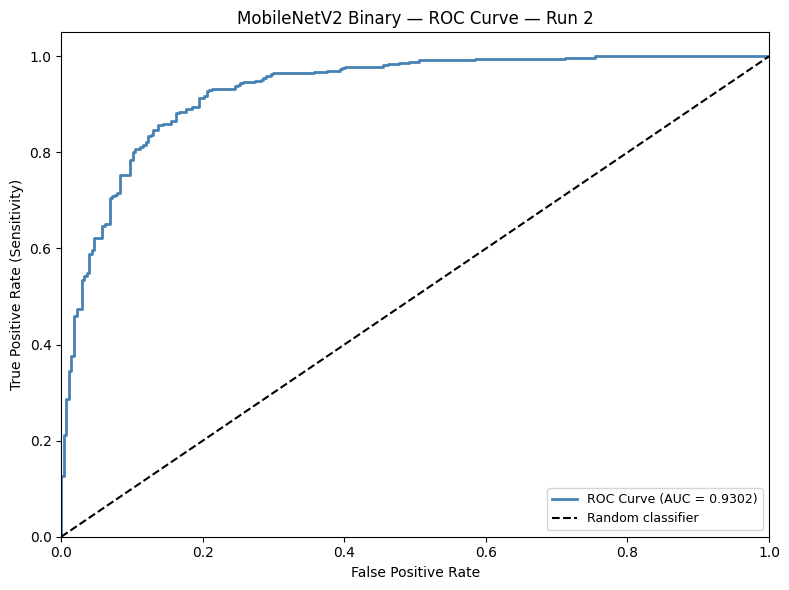

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_roc_curve_run2.png


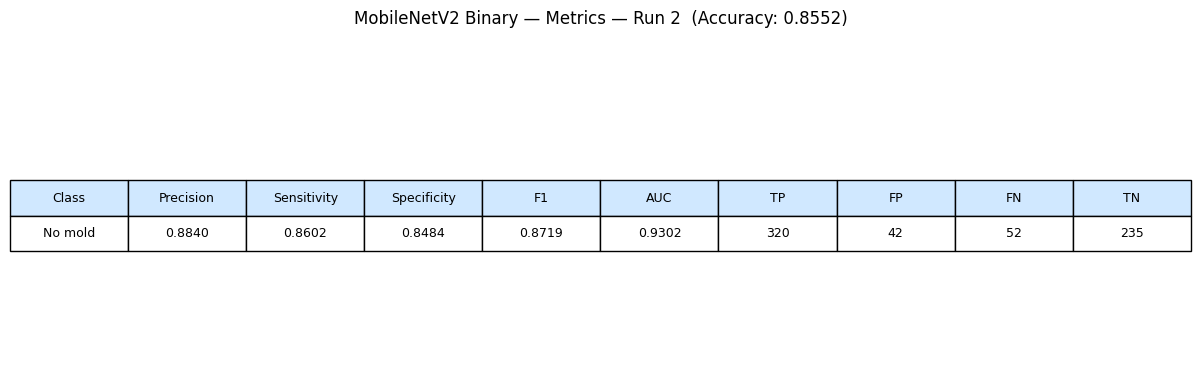

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_metrics_table_run2.png


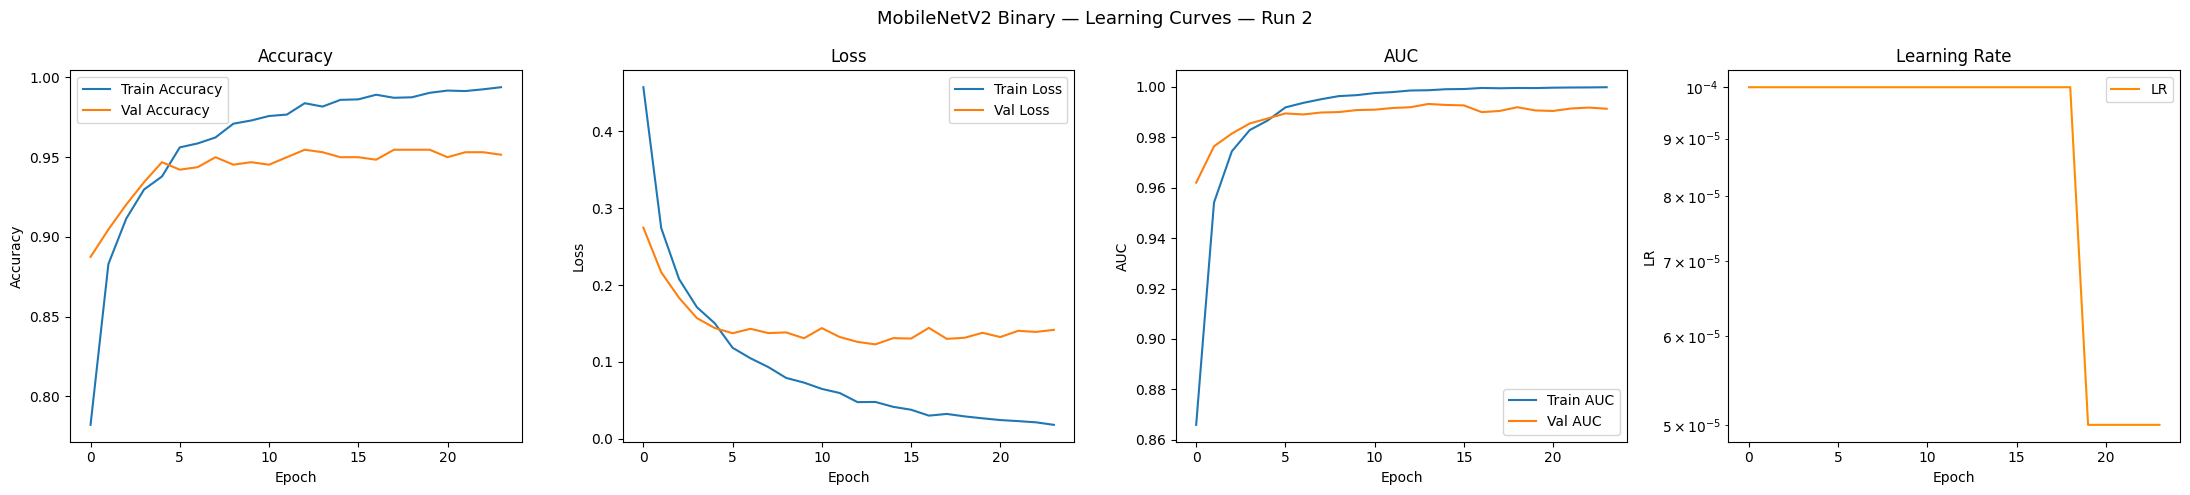

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_learning_curves_run2.png

  Evaluating MobileNetV2 Binary Run 3 / 5
  Checkpoint : D:\Mold Studies Binary\Models\mobilenetv2_binary_run3_best.keras
21/21 [==============================] - 3s 105ms/step

  Run 3 Results
    Accuracy     : 0.8737
    Precision    : 0.8776
    Sensitivity  : 0.9059
    Specificity  : 0.8303
    F1 Score     : 0.8915
    AUC          : 0.9354
    TP=337  TN=230  FP=47  FN=35


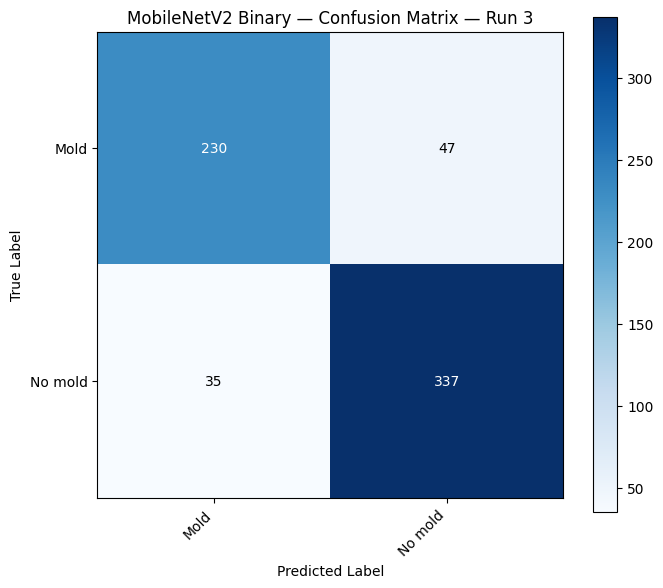

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_confusion_matrix_run3.png


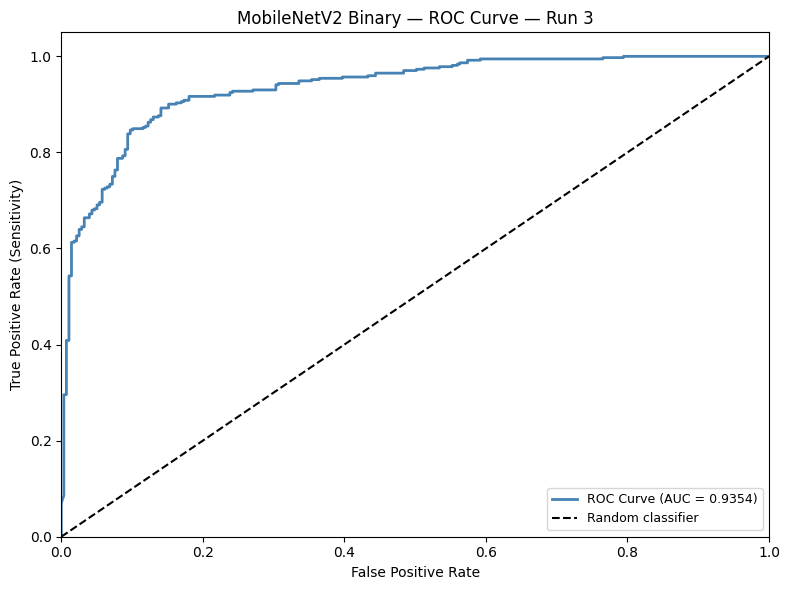

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_roc_curve_run3.png


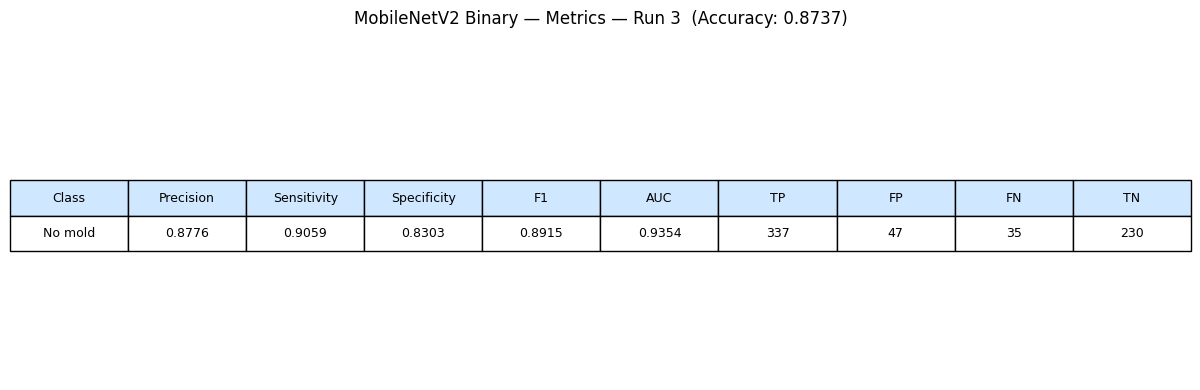

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_metrics_table_run3.png


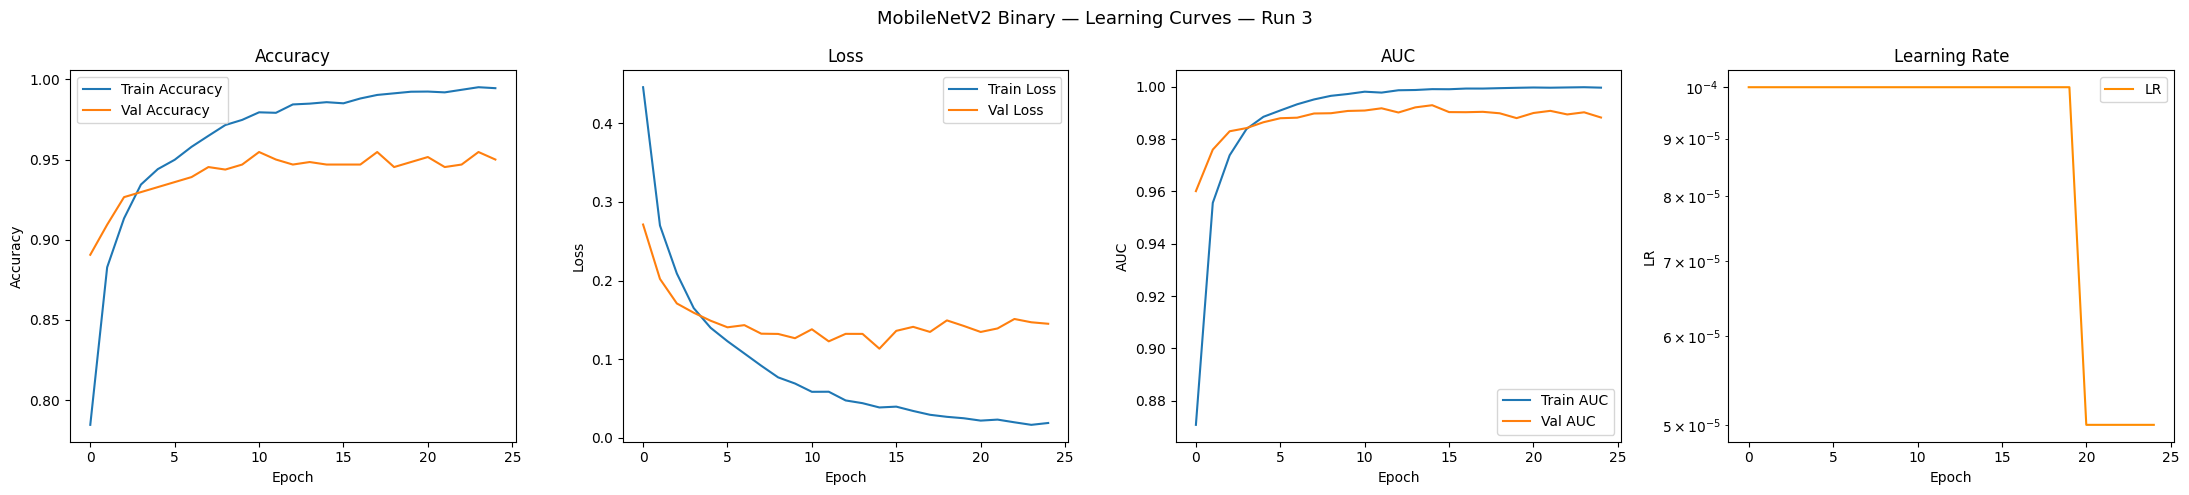

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_learning_curves_run3.png

  Evaluating MobileNetV2 Binary Run 4 / 5
  Checkpoint : D:\Mold Studies Binary\Models\mobilenetv2_binary_run4_best.keras
21/21 [==============================] - 3s 102ms/step

  Run 4 Results
    Accuracy     : 0.8721
    Precision    : 0.8853
    Sensitivity  : 0.8925
    Specificity  : 0.8448
    F1 Score     : 0.8889
    AUC          : 0.9320
    TP=332  TN=234  FP=43  FN=40


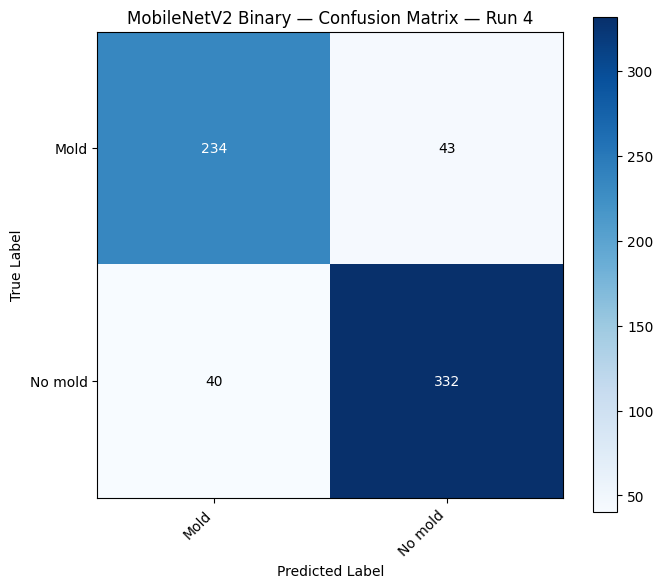

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_confusion_matrix_run4.png


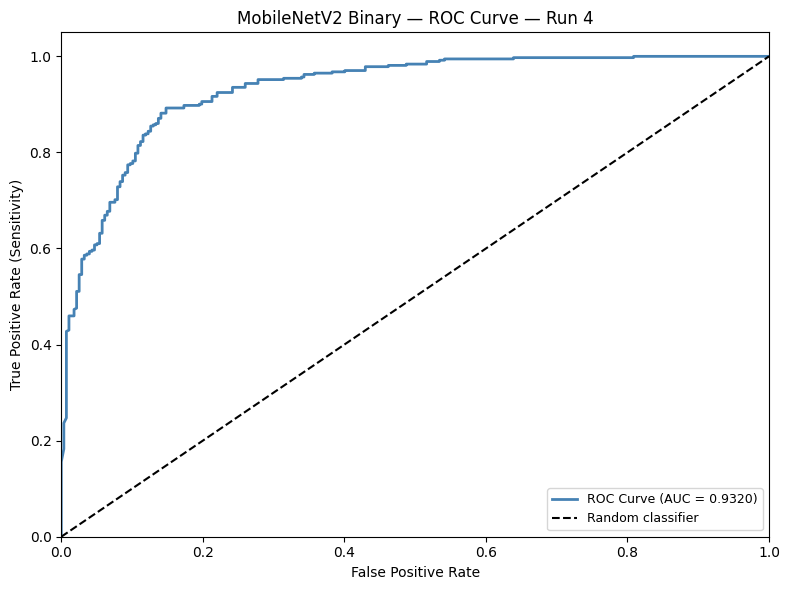

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_roc_curve_run4.png


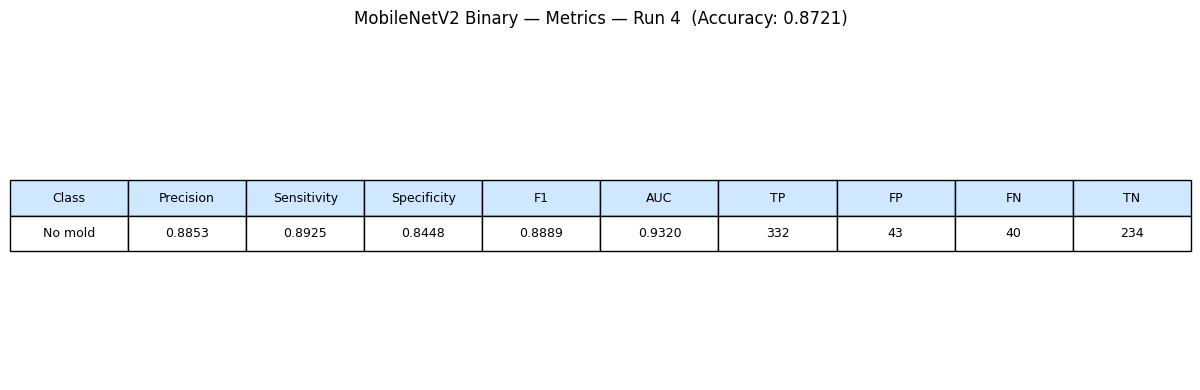

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_metrics_table_run4.png


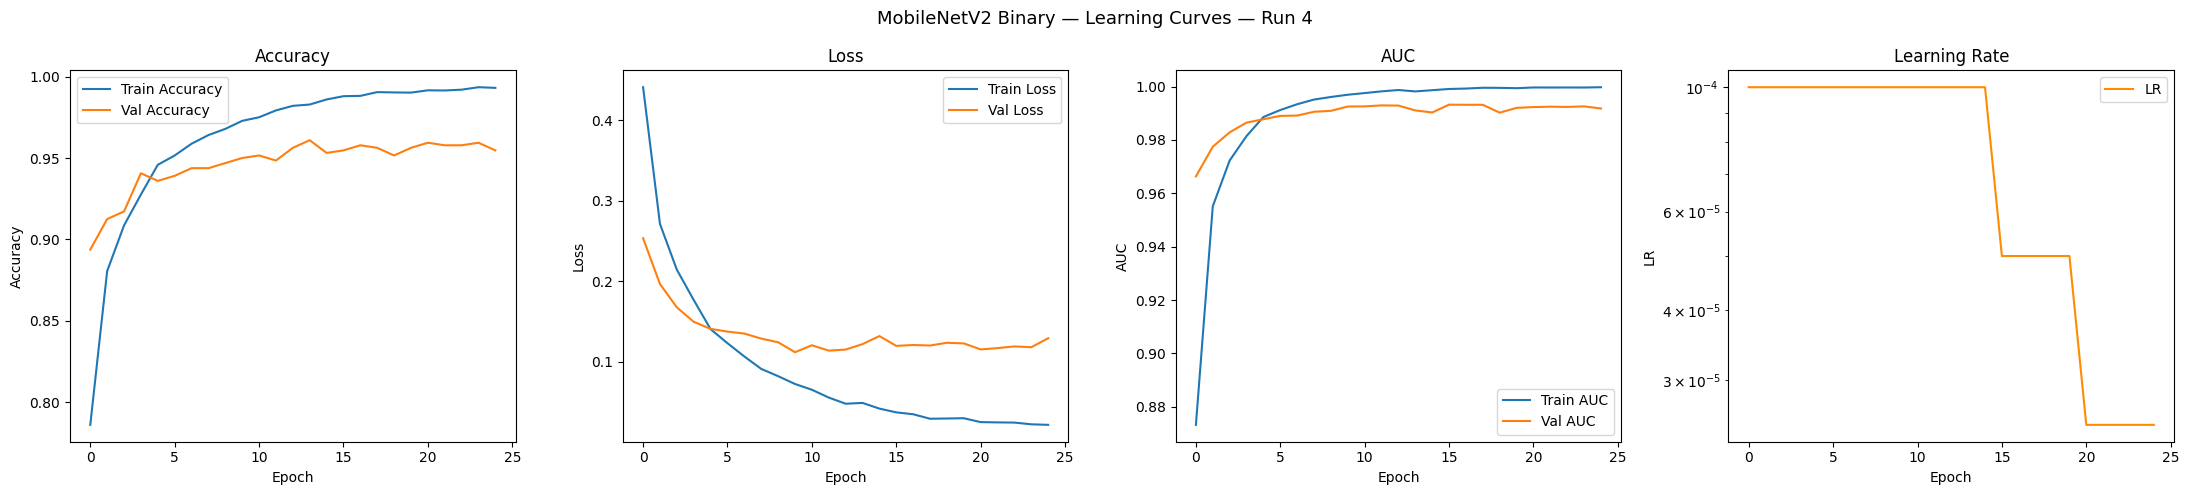

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_learning_curves_run4.png

  Evaluating MobileNetV2 Binary Run 5 / 5
  Checkpoint : D:\Mold Studies Binary\Models\mobilenetv2_binary_run5_best.keras
21/21 [==============================] - 3s 101ms/step

  Run 5 Results
    Accuracy     : 0.8767
    Precision    : 0.8883
    Sensitivity  : 0.8978
    Specificity  : 0.8484
    F1 Score     : 0.8930
    AUC          : 0.9332
    TP=334  TN=235  FP=42  FN=38


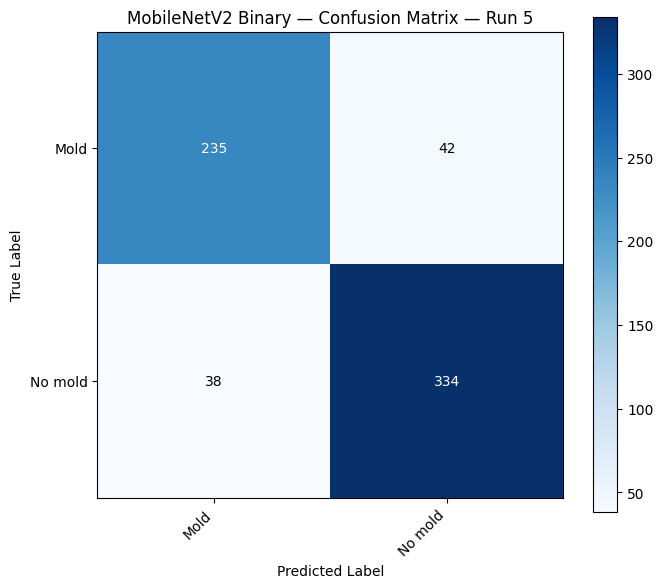

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_confusion_matrix_run5.png


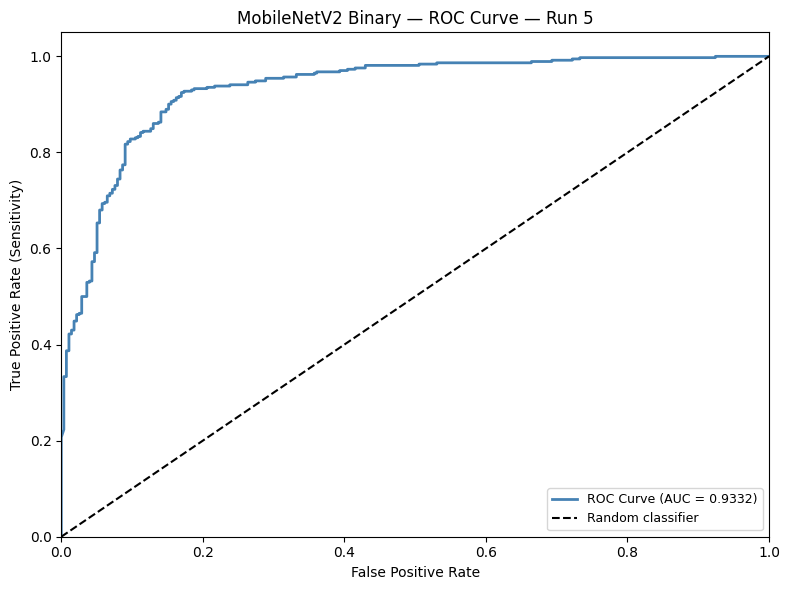

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_roc_curve_run5.png


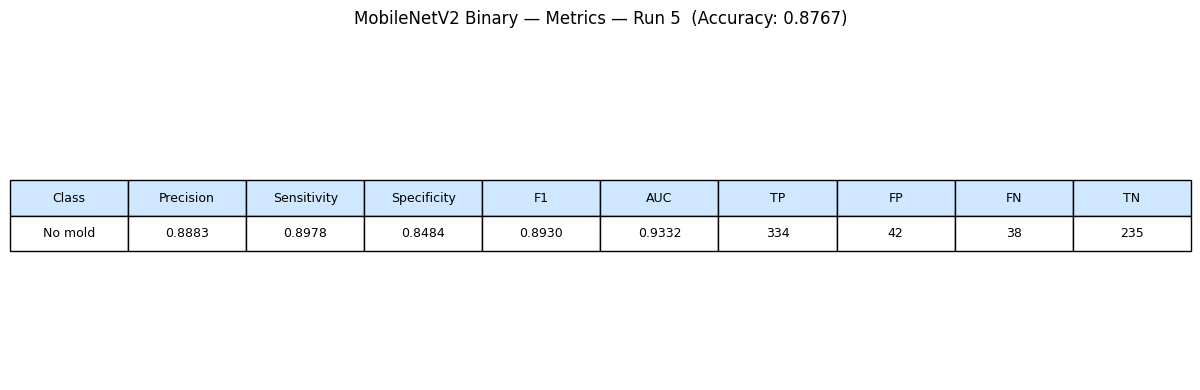

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_metrics_table_run5.png


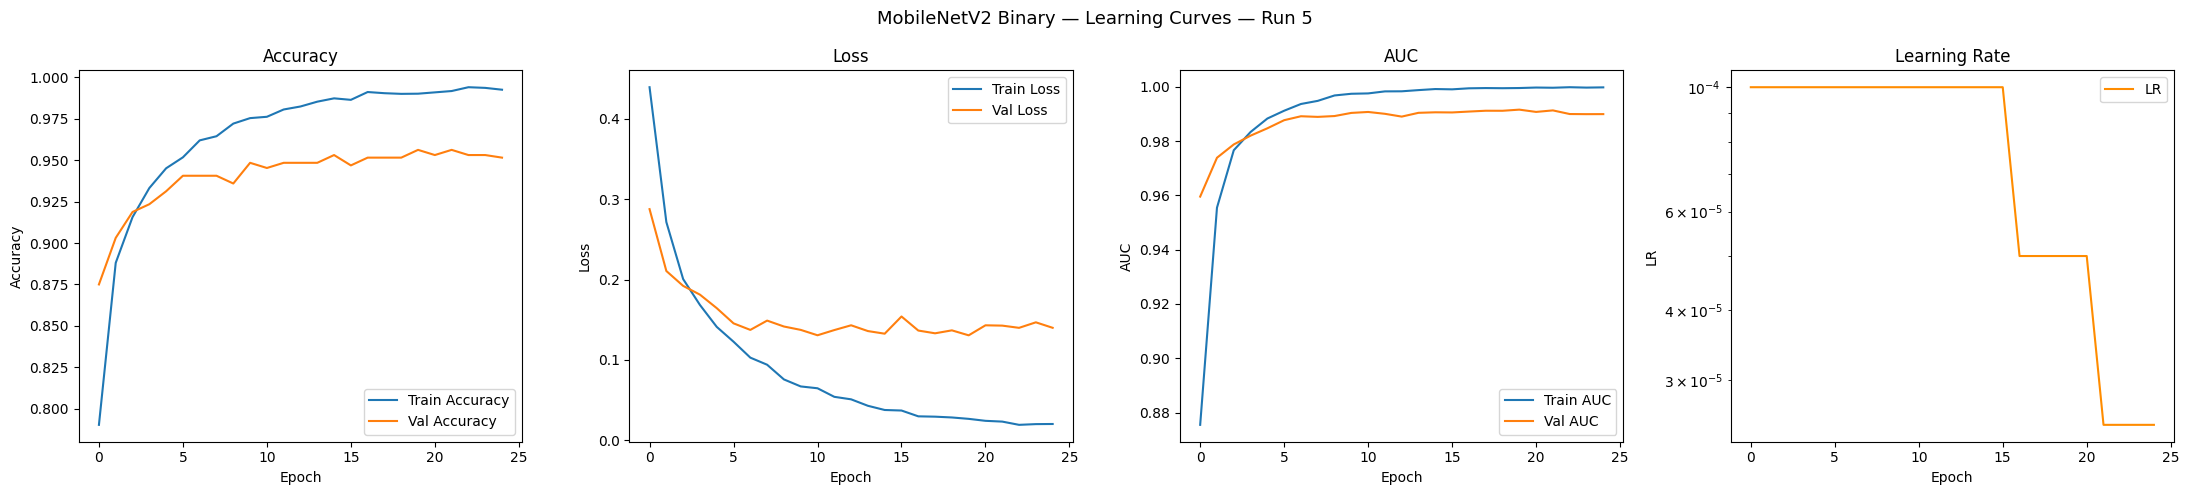

  Saved: D:\Mold Studies Binary\Models\plots\mobilenetv2_binary\mobilenetv2_binary_learning_curves_run5.png

  STATISTICAL SUMMARY — MobileNetV2 Binary — All 5 Runs
  Accuracy      : mean=0.8675  std=0.0084  min=0.8552  max=0.8767
  Precision     : mean=0.8800  std=0.0083  min=0.8649  max=0.8883
  Sensitivity   : mean=0.8903  std=0.0157  min=0.8602  max=0.9059
  Specificity   : mean=0.8368  std=0.0140  min=0.8123  max=0.8484
  F1 Score      : mean=0.8850  std=0.0080  min=0.8719  max=0.8930
  AUC           : mean=0.9330  std=0.0018  min=0.9302  max=0.9354

  PER-RUN RESULTS — MobileNetV2 Binary
  Run       Accuracy   Precision   Sensitivity   Specificity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────────────
  1           0.8598      0.8649        0.8952        0.8123    0.8798    0.9344
  2           0.8552      0.8840        0.8602        0.8484    0.8719    0.9302
  3           0.8737      0.8776        0.9059        0.8303    0.891

In [6]:
"""
Fragment 4 — Evaluation & Metrics
===================================
Binary Mould Classification Pipeline — Mold vs No Mold

Evaluates all 5 trained runs against the test set.
Metrics computed per run and averaged across all runs:
    - Confusion Matrix (2x2)
    - Accuracy
    - Precision
    - Recall (Sensitivity)
    - Specificity
    - F1 Score
    - ROC / AUC (single binary curve)
    - Learning Curves (Accuracy, Loss, AUC, LR)

TEST DATA — loaded fresh here, never seen during training.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies Binary\Mould Binary Classification"
TEST_DIR   = os.path.join(DATA_DIR, "test")
SAVE_DIR   = r"D:\Mold Studies Binary\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "mobilenetv2_binary")

os.makedirs(PLOT_DIR, exist_ok=True)

THRESHOLD  = 0.5
TOTAL_RUNS = 5

# ── Step 1: Load Test Generator ───────────────────────────────────────────────

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    shuffle     = False,
)

CLASS_NAMES = list(test_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("  Step 1 — Test Generator Ready")
print("=" * 60)
print(f"  Architecture  : MobileNetV2 Binary")
print(f"  Preprocessing : preprocess_input (MobileNetV2)")
print(f"  Test samples  : {test_generator.samples}")
print(f"  Classes       : {CLASS_NAMES}")
print(f"  Class indices : {test_generator.class_indices}")
print(f"  Threshold     : {THRESHOLD}")
print(f"  Source        : {TEST_DIR}")
print("=" * 60)

# ── Step 2: Helper Functions ──────────────────────────────────────────────────

def compute_metrics_binary(y_true, y_pred, y_prob):
    """
    Computes full binary evaluation metrics.
    y_prob : raw sigmoid probabilities (N,) for the positive class
    y_pred : thresholded binary predictions (N,)
    y_true : ground truth binary labels (N,)
    """
    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    precision   = tp / (tp + fp + 1e-7)
    recall      = tp / (tp + fn + 1e-7)
    specificity = tn / (tn + fp + 1e-7)
    f1          = 2 * precision * recall / (precision + recall + 1e-7)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-7)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    return {
        "cm"         : cm,
        "tp"         : int(tp),
        "tn"         : int(tn),
        "fp"         : int(fp),
        "fn"         : int(fn),
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "fpr"        : fpr,
        "tpr"        : tpr,
        "auc"        : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"MobileNetV2 Binary — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"mobilenetv2_binary_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_roc_curve(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(
        metrics["fpr"],
        metrics["tpr"],
        color = "steelblue",
        lw    = 2,
        label = f"ROC Curve (AUC = {metrics['auc']:.4f})"
    )
    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")

    ax.set(
        title  = f"MobileNetV2 Binary — ROC Curve — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate (Sensitivity)",
        xlim   = [0.0, 1.0],
        ylim   = [0.0, 1.05],
    )
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"mobilenetv2_binary_roc_curve_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")

    rows = [[
        CLASS_NAMES[1],
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['auc']:.4f}",
        f"{metrics['tp']}",
        f"{metrics['fp']}",
        f"{metrics['fn']}",
        f"{metrics['tn']}",
    ]]

    col_labels = ["Class", "Precision", "Sensitivity",
                  "Specificity", "F1", "AUC",
                  "TP", "FP", "FN", "TN"]

    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 2.0)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#d0e8ff")

    ax.set_title(
        f"MobileNetV2 Binary — Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )

    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"mobilenetv2_binary_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_learning_curves(csv_path, run_idx, save_dir):
    if not os.path.exists(csv_path):
        print(f"  ⚠️  CSV log not found for Run {run_idx}: {csv_path}")
        return

    log = pd.read_csv(csv_path)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(
        f"MobileNetV2 Binary — Learning Curves — Run {run_idx}",
        fontsize=13
    )

    # Accuracy
    axes[0].plot(log["epoch"], log["accuracy"],     label="Train Accuracy")
    axes[0].plot(log["epoch"], log["val_accuracy"], label="Val Accuracy")
    axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[0].legend()

    # Loss
    axes[1].plot(log["epoch"], log["loss"],     label="Train Loss")
    axes[1].plot(log["epoch"], log["val_loss"], label="Val Loss")
    axes[1].set(title="Loss", xlabel="Epoch", ylabel="Loss")
    axes[1].legend()

    # AUC
    if "auc" in log.columns:
        axes[2].plot(log["epoch"], log["auc"],     label="Train AUC")
        axes[2].plot(log["epoch"], log["val_auc"], label="Val AUC")
        axes[2].set(title="AUC", xlabel="Epoch", ylabel="AUC")
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, "AUC not logged",
                     ha="center", va="center",
                     transform=axes[2].transAxes)
        axes[2].set_title("AUC")

    # Learning Rate
    if "lr" in log.columns:
        axes[3].plot(log["epoch"], log["lr"],
                     color="darkorange", label="LR")
        axes[3].set(title="Learning Rate", xlabel="Epoch", ylabel="LR")
        axes[3].set_yscale("log")
        axes[3].legend()
    else:
        axes[3].text(0.5, 0.5, "LR not logged",
                     ha="center", va="center",
                     transform=axes[3].transAxes)
        axes[3].set_title("Learning Rate")

    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"mobilenetv2_binary_learning_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")

# ── Step 3: Evaluate All 5 Runs ───────────────────────────────────────────────

all_metrics = []

for r in all_run_results:
    run_idx  = r["run"]
    ckpt     = os.path.join(SAVE_DIR, r["checkpoint"])
    csv_path = os.path.join(
        SAVE_DIR,
        "mobilenetv2_binary_training_log.csv" if run_idx == 1
        else f"mobilenetv2_binary_run{run_idx}_log.csv"
    )

    print(f"\n{'='*60}")
    print(f"  Evaluating MobileNetV2 Binary Run {run_idx} / {TOTAL_RUNS}")
    print(f"  Checkpoint : {ckpt}")
    print(f"{'='*60}")

    run_model = tf.keras.models.load_model(ckpt)

    test_generator.reset()

    # Sigmoid output — squeeze (N,1) to (N,)
    y_prob = run_model.predict(
        test_generator,
        steps   = np.ceil(test_generator.samples / BATCH_SIZE),
        verbose = 1,
    ).squeeze()

    y_pred = (y_prob >= THRESHOLD).astype(int)
    y_true = test_generator.classes

    metrics        = compute_metrics_binary(y_true, y_pred, y_prob)
    metrics["run"] = run_idx
    all_metrics.append(metrics)

    print(f"\n  Run {run_idx} Results")
    print(f"    Accuracy     : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Sensitivity  : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    AUC          : {metrics['auc']:.4f}")
    print(f"    TP={metrics['tp']}  TN={metrics['tn']}  "
          f"FP={metrics['fp']}  FN={metrics['fn']}")

    plot_confusion_matrix(metrics["cm"],  run_idx, PLOT_DIR)
    plot_roc_curve(metrics,               run_idx, PLOT_DIR)
    plot_metrics_table(metrics,           run_idx, PLOT_DIR)
    plot_learning_curves(csv_path,        run_idx, PLOT_DIR)

# ── Step 4: Statistical Summary Across All 5 Runs ────────────────────────────

print(f"\n{'='*60}")
print(f"  STATISTICAL SUMMARY — MobileNetV2 Binary — All {TOTAL_RUNS} Runs")
print(f"{'='*60}")

metric_keys = {
    "Accuracy"   : "accuracy",
    "Precision"  : "precision",
    "Sensitivity": "recall",
    "Specificity": "specificity",
    "F1 Score"   : "f1",
    "AUC"        : "auc",
}

for label, key in metric_keys.items():
    vals = [m[key] for m in all_metrics]
    print(f"  {label:<14}: "
          f"mean={np.mean(vals):.4f}  "
          f"std={np.std(vals):.4f}  "
          f"min={np.min(vals):.4f}  "
          f"max={np.max(vals):.4f}")

print(f"{'='*60}")

# ── Step 5: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_acc  = 12
col_prec = 12
col_sens = 14
col_spec = 14
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)

print(f"\n{divider}")
print(f"  PER-RUN RESULTS — MobileNetV2 Binary")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'Accuracy':>{col_acc}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'Specificity':>{col_spec}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for m in all_metrics:
    print(
        f"  {m['run']:<{col_run}}"
        f"{m['accuracy']:>{col_acc}.4f}"
        f"{m['precision']:>{col_prec}.4f}"
        f"{m['recall']:>{col_sens}.4f}"
        f"{m['specificity']:>{col_spec}.4f}"
        f"{m['f1']:>{col_f1}.4f}"
        f"{m['auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 6: Best Run ──────────────────────────────────────────────────────────

best_metrics = max(all_metrics, key=lambda x: x["auc"])

print(f"\n  Best run     : Run {best_metrics['run']} (by AUC)")
print(f"  Accuracy     : {best_metrics['accuracy']:.4f}")
print(f"  Sensitivity  : {best_metrics['recall']:.4f}")
print(f"  Specificity  : {best_metrics['specificity']:.4f}")
print(f"  F1 Score     : {best_metrics['f1']:.4f}")
print(f"  AUC          : {best_metrics['auc']:.4f}")
print(f"  TP={best_metrics['tp']}  TN={best_metrics['tn']}  "
      f"FP={best_metrics['fp']}  FN={best_metrics['fn']}")

# ── Step 7: Expose for comparison ─────────────────────────────────────────────

mobilenetv2_binary_all_metrics     = all_metrics
mobilenetv2_binary_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 4 complete.")
print(f"     mobilenetv2_binary_all_metrics and")
print(f"     mobilenetv2_binary_all_run_results are ready.\n")